In [1]:
import pandas as pd
import numpy as np
import random
import torch

In [2]:
import ast

In [3]:
sensitive_boundaries_results_path = "/scratch1/smaruj/sensitive_boundary_results.tsv"
df = pd.read_csv(sensitive_boundaries_results_path, sep="\t")

In [4]:
df["disrupted_bin"] = df["disrupted_bin"].apply(ast.literal_eval)

In [5]:
df

,chrom,start,end,window_end,window_start,disrupted_bin,SCD,RUQ_mean
0,chr1,4400000,4410000,5061504,3750784,[261],2.120519,0.000731
1,chr1,4770000,4780000,5431504,4120784,"[252, 243, 253, 258]",14.721539,0.017108
2,chr1,5150000,5160000,5811504,4500784,"[247, 269]",3.607144,0.001020
3,chr1,5900000,5910000,6561504,5250784,"[255, 260]",11.613214,-0.019208
4,chr1,6190000,6200000,6851504,5540784,[253],6.115497,0.009087
...,...,...,...,...,...,...,...,...
3910,chr9,121450000,121460000,122111504,120800784,"[257, 266, 267]",8.670380,0.015198
3911,chr9,121700000,121710000,122361504,121050784,"[251, 243]",8.649242,0.008415
3912,chr9,122350000,122360000,123011504,121700784,[253],39.628345,-0.042670
3913,chr9,122720000,122730000,123381504,122070784,"[257, 261]",3.258348,-0.004068


In [6]:
filtered_sorted_neg_df = (
    df[df["RUQ_mean"] < 0]
    .sort_values(by="RUQ_mean")
    .reset_index(drop=True)
)

In [7]:
len(filtered_sorted_neg_df)

1403

In [8]:
import matplotlib.pyplot as plt

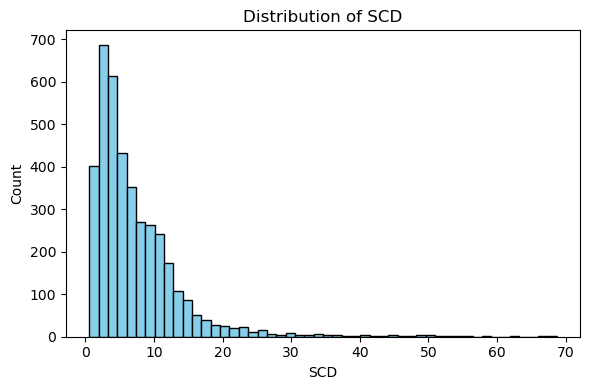

In [9]:
# Plot SCD histogram
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of SCD")
plt.xlabel("SCD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

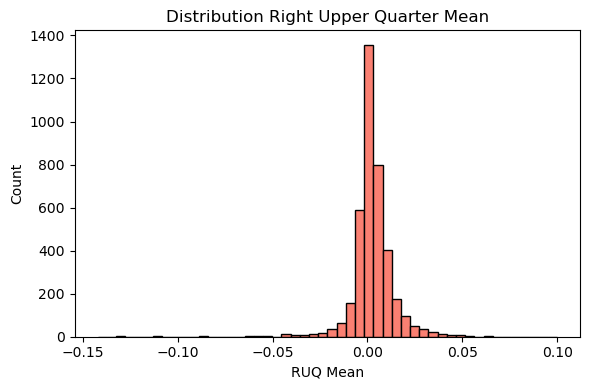

In [10]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
plt.hist(df["RUQ_mean"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Right Upper Quarter Mean")
plt.xlabel("RUQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
df["RUQ_mean"].min()

-0.14213617

In [12]:
df["RUQ_mean"].mean()

0.0025062380187019923

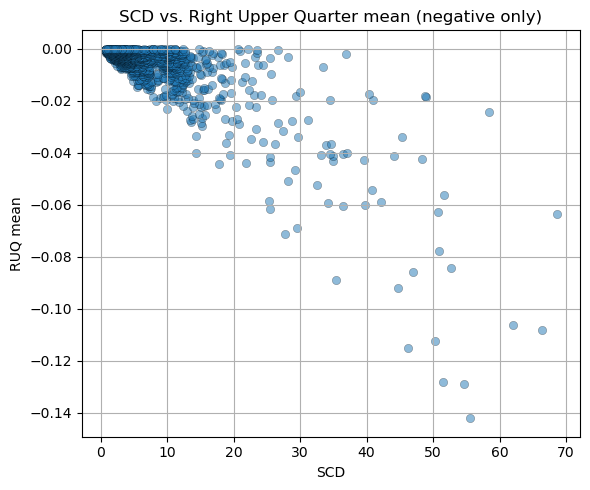

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(
    filtered_sorted_neg_df["SCD"],
    filtered_sorted_neg_df["RUQ_mean"],
    alpha=0.5,
    edgecolors="k",
    linewidths=0.3
)
plt.title("SCD vs. Right Upper Quarter mean (negative only)")
plt.xlabel("SCD")
plt.ylabel("RUQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

## CTCFs analysis

In [14]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [15]:
from pyfaidx import Fasta

In [16]:
fasta_file = "/project/fudenber_735/genomes/hg38/hg38.fa"
genome = Fasta(fasta_file)

In [17]:
def group_consecutive_bins(bins):
    bins = sorted(bins)
    grouped = []
    current_group = [bins[0]]

    for b in bins[1:]:
        if b == current_group[-1] + 1:
            current_group.append(b)
        else:
            grouped.append(current_group)
            current_group = [b]
    grouped.append(current_group)
    return grouped

In [18]:
def get_sequence(genome, chrom, start, bin_list, cropping=64, bin_size=2048):
    if len(bin_list) == 1:
        bin_start = start + (bin_list[0] + cropping) * bin_size
        bin_end = bin_start + bin_size
    else:
        bin_start = start + (min(bin_list) + cropping) * bin_size
        bin_end = bin_start + len(bin_list) * bin_size
    seq = genome[chrom][bin_start:bin_end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [19]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [20]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [21]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [22]:
from tangermeme.tools import fimo

In [24]:
all_hits = []

for idx, row in filtered_sorted_neg_df.iterrows():
    chrom = row["chrom"]
    window_start = row["window_start"]
    window_end = row["window_end"]
    scd = row["SCD"]
    ruq = row["RUQ_mean"]
    all_bins = row["disrupted_bin"]
    grouped_bins = group_consecutive_bins(all_bins)
    
    for gr_bins in grouped_bins:
        sequence = get_sequence(genome, chrom, window_start, gr_bins)

        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=sequence,
            threshold=1e-4,
            reverse_complement=True
        )[0]

        # Only add non-empty results
        if not hits.empty:
            hits["chrom"] = chrom
            hits["window_start"] = window_start
            hits["window_end"] = window_end
            hits["bin_group"] = str(gr_bins)
            hits["scd"] = scd
            hits["RUQ_mean"] = ruq
            all_hits.append(hits)

In [25]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [26]:
combined_hits_df

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value,chrom,window_start,window_end,bin_group,scd,RUQ_mean
0,CTCF,0,0,527,546,-,8.756583,0.000087,chr13,53120784,54431504,[255],55.537971,-0.142136
1,CTCF,0,0,290,309,+,16.950388,0.000001,chr13,53120784,54431504,[259],55.537971,-0.142136
2,CTCF,0,0,1157,1176,-,12.410929,0.000015,chr13,53120784,54431504,[259],55.537971,-0.142136
3,CTCF,0,0,6,25,+,17.016524,0.000001,chr5,4820784,6131504,[264],54.602184,-0.128920
4,CTCF,0,0,1303,1322,-,16.845432,0.000001,chr18,75700784,77011504,[252],51.467289,-0.128222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1078,CTCF,0,0,1255,1274,-,12.781228,0.000013,chr13,31620784,32931504,[254],3.576016,-0.000102
1079,CTCF,0,0,602,621,-,9.087952,0.000076,chr11,85180784,86491504,[269],9.060363,-0.000058
1080,CTCF,0,0,1053,1072,-,8.706508,0.000087,chr5,82850784,84161504,[262],1.789079,-0.000057
1081,CTCF,0,0,1141,1160,-,11.411790,0.000025,chr5,82850784,84161504,[262],1.789079,-0.000057


In [ ]:
# grouped_df = combined_hits_df.groupby(
#     ["chrom", "window_start", "window_end", "scd", "bound_strength"], as_index=False
# ).agg(
#     score_sum=("score", "sum"),
#     motif_count=("score", "count"),
#     strand_concat=("strand", lambda x: ",".join(x.astype(str)))
# )

In [ ]:
# grouped_df = combined_hits_df.groupby(
#     ["chrom", "window_start", "window_end", "scd", "bound_strength"], as_index=False
# ).agg(
#     score_mean=("score", "mean"),
#     motif_count=("score", "count"),
#     strand_concat=("strand", lambda x: ",".join(x.astype(str)))
# )

In [28]:
grouped_df = combined_hits_df.groupby(
    ["chrom", "window_start", "window_end", "scd", "RUQ_mean"], as_index=False
).agg(
    score_max=("score", "max"),
    motif_count=("score", "count"),
    strand_concat=("strand", lambda x: ",".join(x.astype(str)))
)

In [29]:
grouped_df

,chrom,window_start,window_end,scd,RUQ_mean,score_max,motif_count,strand_concat
0,chr1,5250784,6561504,11.613214,-0.019208,15.926706,2,"+,-"
1,chr1,6330784,7641504,12.107278,-0.002200,10.218154,2,"+,-"
2,chr1,6580784,7891504,50.234745,-0.112513,13.078437,3,"+,-,-"
3,chr1,13460784,14771504,10.963421,-0.018936,10.765602,1,+
4,chr1,16990784,18301504,4.695704,-0.006829,16.226189,2,"-,-"
...,...,...,...,...,...,...,...,...
624,chr9,100600784,101911504,4.616183,-0.008108,8.919204,1,-
625,chr9,101950784,103261504,2.434124,-0.002819,8.499914,1,-
626,chr9,103340784,104651504,2.728431,-0.001554,8.658689,1,+
627,chr9,112150784,113461504,6.001436,-0.007159,19.957041,1,-


In [30]:
grouped_df["motif_count"].mean(), grouped_df["motif_count"].min(), grouped_df["motif_count"].max()

(1.7217806041335453, 1, 7)

In [31]:
def strand_bias(s):
    strands = list(s)
    if not strands:
        return 0.5
    return strands.count("+") / len(strands)

grouped_df["strand_bias"] = grouped_df["strand_concat"].apply(strand_bias)

In [ ]:
# multiple = grouped_df[grouped_df["motif_count"] > 1]

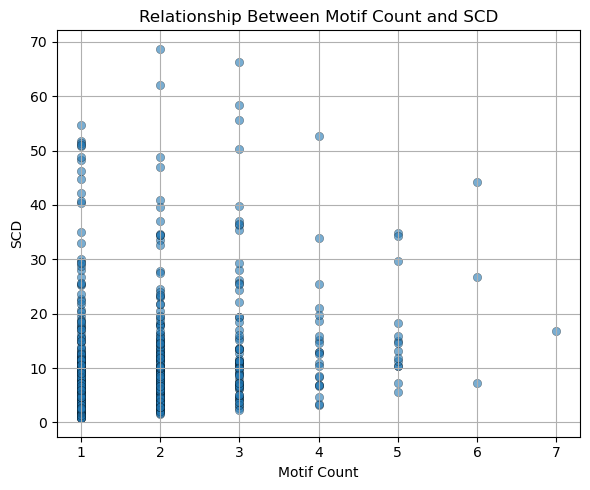

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)
plt.title("Relationship Between Motif Count and SCD")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

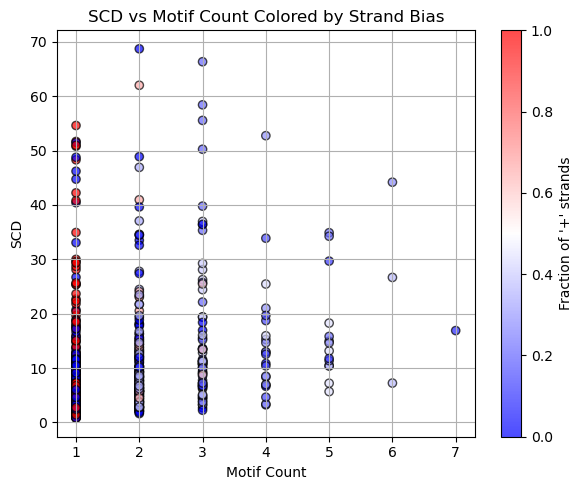

In [33]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("SCD vs Motif Count Colored by Strand Bias")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

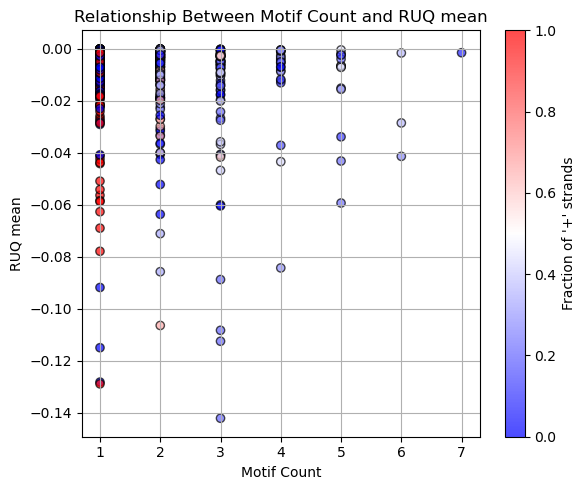

In [34]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["RUQ_mean"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("Relationship Between Motif Count and RUQ mean")
plt.xlabel("Motif Count")
plt.ylabel("RUQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
from scipy.stats import pearsonr

# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_max"], grouped_df["scd"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [36]:
corr_text

'r = 0.51, p = 4.34e-43'

In [37]:
x = grouped_df["score_max"]
y = grouped_df["scd"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

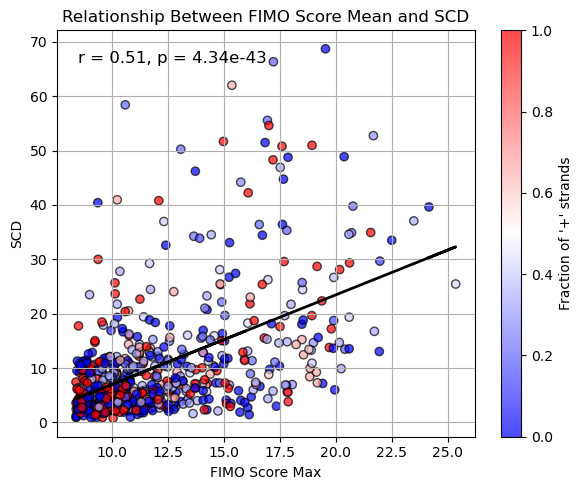

In [38]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_max"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.title("Relationship Between FIMO Score Mean and SCD")
plt.xlabel("FIMO Score Max")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_max"], grouped_df["RUQ_mean"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [40]:
x = grouped_df["score_max"]
y = grouped_df["RUQ_mean"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

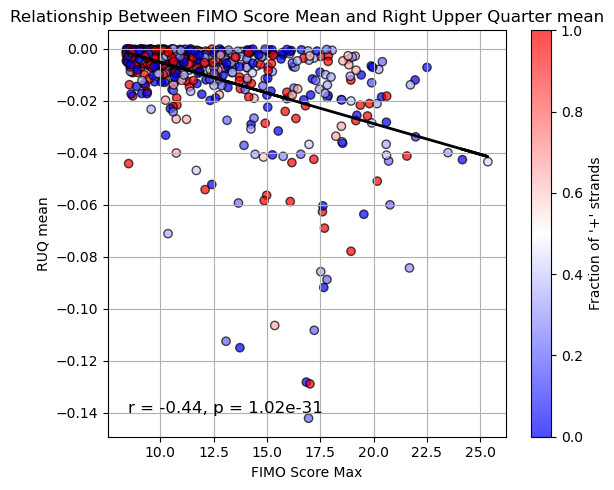

In [41]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_max"],
    grouped_df["RUQ_mean"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Mean and Right Upper Quarter mean")
plt.xlabel("FIMO Score Max")
plt.ylabel("RUQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

## Multiple CTCFs

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    multiple["score_mean"],
    multiple["bound_strength"],
    c=multiple["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("Relationship Between FIMO Score Mean and Boundary Strength")
plt.xlabel("FIMO Score Mean")
plt.ylabel("Boundary Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
multiple